В файле **WIPO-GII_2022.xlsx** содержаться данные по странам о показателях, используемых для расчета Global Innovation Index за 2022 год.

### В файле следующие переменные:
- Country
- Business environment
- Business sophistication index
- Citable documents H-index
- Creative goods and services
- Creative goods exports, % total trade
- Creative outputs index
- Cultural and creative services exports, % total trade
- Domestic market scale, bn PPP
- Ecological sustainability
- Expenditure on education, % GDP
- Firms offering formal training, %
- General infrastructure
- Government effectiveness
- Government's online service
- Graduates in science and engineering, %
- Gross expenditure on R&D, % GDP
- High-tech exports, % total trade
- High-tech imports, % total trade
- High-tech manufacturing, %
- Human capital and research index
- Information and Communications Technology access
- Information and Communications Technology services exports, % total trade
- Information and Communications Technology services imports, % total trade
- Information and Communications Technology use
- Infrastructure index
- Intangible assets
- Joint venture/strategic alliance deals/bn PPP GDP
- Knowledge absorption
- Knowledge and technology outputs index
- Knowledge workers
- Knowledge-intensive employment, %
- Logistics performance
- Market sophistication index
- Mobile app creation/bn PPP GDP
- Online creativity
- PISA scales in reading, maths and science
- Political and operational stability
- Political environment
- Pupil-teacher ratio, secondary
- QS university ranking average score of top 3 universities
- Research and development (R&D)
- Scientific and technical articles/bn PPP GDP
- Software spending, % GDP
- Tertiary education
- Tertiary enrolment, % gross
- University-industry R&D collaboration
- Region
- Region2
- Euro area
- European Union
- OECD members
- Least developed countries
- Income
- High income

Выполните, пожалуйста, задания.

In [ ]:
import pandas as pd
%matplotlib inline
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_excel('WIPO-GII_2022.xlsx')
df

,Country,Business environment_2022,Business sophistication index_2022,Citable documents H-index_2022,Creative goods and services_2022,"Creative goods exports, % total trade_2022",Creative outputs index_2022,"Cultural and creative services exports, % total trade_2022","Domestic market scale, bn PPP$_2022",Ecological sustainability_2022,...,"Tertiary enrolment, % gross_2022",University-industry R&D collaboration_2022,Region,Region2,Euro area,European Union,OECD members,Least developed countries,Income,High income
0,Cote d'Ivoire,48.3,21.8,5.1,1.2,0.3,6.0,2.1,3.4,23.7,...,4.0,38.5,Sub-Saharan Africa,Sub-Saharan Africa,0,0,0,0,middle income,0
1,Czechia,42.1,46.2,30.4,40.6,100.0,29.9,15.3,10.3,47.3,...,42.6,59.1,Europe & Central Asia,Europe,0,1,1,0,high income,1
2,"Egypt, Arab Rep.",45.0,20.4,18.0,9.1,16.9,14.1,0.0,30.9,25.4,...,24.1,47.0,Middle East & North Africa,Middle East and North Africa,0,0,0,0,middle income,0
3,"Hong Kong SAR, China",69.7,46.7,38.4,47.4,100.0,53.2,3.0,10.8,56.3,...,55.6,62.9,East Asia & Pacific,Asia-Pacific,0,0,0,0,high income,1
4,"Iran, Islamic Rep.",13.3,18.6,22.1,4.0,1.2,31.8,4.2,26.6,14.7,...,37.5,27.7,Middle East & North Africa,Middle East and North Africa,0,0,0,0,middle income,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Paraguay,28.8,23.1,3.2,0.6,1.1,18.1,0.1,2.1,25.2,...,0.0,26.8,Latin America & Caribbean,Americas,0,0,0,0,middle income,0
135,Peru,50.4,32.1,14.4,12.6,2.7,19.5,2.6,10.0,31.6,...,46.1,32.7,Latin America & Caribbean,Americas,0,0,0,0,middle income,0
136,Trinidad and Tobago,47.6,20.5,4.0,1.7,1.7,4.5,0.0,0.6,17.1,...,0.0,33.6,Latin America & Caribbean,Americas,0,0,0,0,high income,1
137,United States,75.3,64.5,100.0,44.8,33.8,48.4,38.8,100.0,25.4,...,58.0,79.6,North America,Americas,0,0,1,0,high income,1


1. Выберите не менее 5 интересующих Вас метрических переменных для последующего проведения кластерного анализа данных. Приведите аргументы в пользу возможности их использования для кластеризации.

In [ ]:
# Находим все метрические переменные
df.select_dtypes(include=['number']).columns.tolist()

['Business environment_2022',
 'Business sophistication index_2022',
 'Citable documents H-index_2022',
 'Creative goods and services_2022',
 'Creative goods exports, % total trade_2022',
 'Creative outputs index_2022',
 'Cultural and creative services exports, % total trade_2022',
 'Domestic market scale, bn PPP$_2022',
 'Ecological sustainability_2022',
 'Expenditure on education, % GDP_2022',
 'Firms offering formal training, %_2022',
 'General infrastructure_2022',
 'Government effectiveness_2022',
 "Government's online service_2022",
 'Graduates in science and engineering, %_2022',
 'Gross expenditure on R&D, % GDP_2022',
 'High-tech exports, % total trade_2022',
 'High-tech imports, % total trade_2022',
 'High-tech manufacturing, %_2022',
 'Human capital and research index_2022',
 'Information and Communications Technology access_2022',
 'Information and Communications Technology services exports, % total trade_2022',
 'Information and Communications Technology services imports, 

Рассмотрим эти переменные:     
*   Pupil-teacher ratio, secondary_2022
*   Ecological sustainability_2022
*   Domestic market scale, bn PPP$_2022
*   High-tech exports, % total trade_2022
*   Political environment_2022

Исходя из их содержательного смысла, переменные отвечают за различные и независимые сферы социального, экономического и технологического развития страны.

Для проверки рассчитаем матрицу коэффициентов корреляции.

In [ ]:
# Стандартизируем значения переменных
df['z_Pupil-teacher ratio, secondary_2022'] = (df['Pupil-teacher ratio, secondary_2022'] - df['Pupil-teacher ratio, secondary_2022'].mean())/df['Pupil-teacher ratio, secondary_2022'].std()
df['z_Ecological sustainability_2022'] = (df['Ecological sustainability_2022'] - df['Ecological sustainability_2022'].mean())/df['Ecological sustainability_2022'].std()
df['z_Domestic market scale, bn PPP$_2022'] = (df['Domestic market scale, bn PPP$_2022'] - df['Domestic market scale, bn PPP$_2022'].mean())/df['Domestic market scale, bn PPP$_2022'].std()
df['z_High-tech exports, % total trade_2022'] = (df['High-tech exports, % total trade_2022'] - df['High-tech exports, % total trade_2022'].mean())/df['High-tech exports, % total trade_2022'].std()
df['z_Political environment_2022'] = (df['Political environment_2022'] - df['Political environment_2022'].mean())/df['Political environment_2022'].std()

variables = [
    'z_Pupil-teacher ratio, secondary_2022',
    'z_Ecological sustainability_2022',
    'z_Domestic market scale, bn PPP$_2022',
    'z_High-tech exports, % total trade_2022',
    'z_Political environment_2022'
]

# Строим таблицу корреляции
df[variables].corr()

,"z_Pupil-teacher ratio, secondary_2022",z_Ecological sustainability_2022,"z_Domestic market scale, bn PPP$_2022","z_High-tech exports, % total trade_2022",z_Political environment_2022
"z_Pupil-teacher ratio, secondary_2022",1.000000,0.398700,0.011101,0.331736,0.435145
z_Ecological sustainability_2022,0.398700,1.000000,0.022262,0.466537,0.555735
"z_Domestic market scale, bn PPP$_2022",0.011101,0.022262,1.000000,0.446094,0.198067
"z_High-tech exports, % total trade_2022",0.331736,0.466537,0.446094,1.000000,0.580262
z_Political environment_2022,0.435145,0.555735,0.198067,0.580262,1.000000


По таблице видно, что корреляция между переменными не превышает 0.58, что свидетельствует об отсутствии сильной взаимосвязи. Данные переменные подходят для кластерного анализа.

2. Выберите подходящий алгоритм кластеризации и обоснуйте свой выбор. Определите число кластеров, объясните своё решение. Опишите получившиеся кластеры с помощью описательной статистки. Нужно не просто рассчитать статистики в таблицах, но детально описать полученные результаты. Дайте названия кластерам и обоснуйте их.

Для выборки объемом 139 наблюдений и при отсутствии предположений о количестве кластеров был выбран алгоритм иерархической кластеризации с применением метода Варда.

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

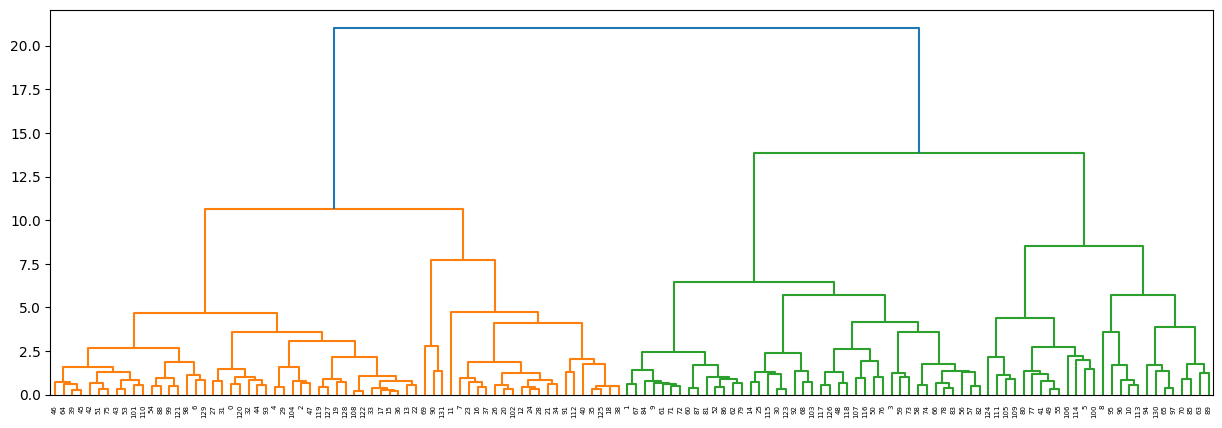

In [ ]:
# Удаляем строки с пропущенными значениями
df1 = df[variables].dropna()

# Строим дендограмму
plt.figure(figsize=(15, 5))
dn = dendrogram(linkage(df1, 'ward'))

На основе визуального анализа дендрограммы выдвинута гипотеза о наличии трёх или четырёх кластеров. Для проверки гипотезы рассчитаем индекс Калински-Харабаза.

In [ ]:
from sklearn.metrics import calinski_harabasz_score

In [ ]:
Z = linkage(df1, method='ward', metric='euclidean')
for k in range (2, 10):
    labels = fcluster(Z, t=k, criterion='maxclust')
    print('Число кластеров: {}, индекс {}'.format(k, calinski_harabasz_score(df1, labels)))

Число кластеров: 2, индекс 65.97927513017297
Число кластеров: 3, индекс 60.354807605699555
Число кластеров: 4, индекс 56.47043065743081
Число кластеров: 5, индекс 52.95694188686359
Число кластеров: 6, индекс 51.336254160526146
Число кластеров: 7, индекс 49.18183838836161
Число кластеров: 8, индекс 47.303175141222454
Число кластеров: 9, индекс 46.726758636248775


Максимальное значение индекса достигается при 2 кластерах, но это слишком мало для содержательного анализа. Поэтому выбираем 3 кластера, соответствующее второму максимальному значению индекса.

In [ ]:
labels = fcluster(Z, t=3, criterion='maxclust')
df1['culster_labels'] = labels
df1.groupby('culster_labels').mean(numeric_only=True).T

culster_labels,1,2,3
"z_Pupil-teacher ratio, secondary_2022",-0.483000,0.615620,0.236714
z_Ecological sustainability_2022,-0.681511,1.009243,0.112279
"z_Domestic market scale, bn PPP$_2022",-0.361916,-0.422165,1.570513
"z_High-tech exports, % total trade_2022",-0.669925,0.240271,1.295924
z_Political environment_2022,-0.666665,0.680389,0.593742


Кластер 1: "Отсталые страны"

Обоснование названия: Все значения значительно ниже среднего.

Характеристики:
- Наихудшие показатели по экологической устойчивости (-0.68) и политической среде (-0.67)
- Низкая доля высокотехнологичного экспорта (-0.67)
- Проблемы в образовательной системе (-0.48)
- Относительно лучше показатели только по размеру рынка (-0.36)

Кластер 2: "Сбалансированно развитые страны"

Обоснование названия: Высокие значения по экологии, образованию и политической стабильности при среднем технологическом экспорте и малом рынке

Характеристики:
- Лидер по экологической устойчивости (1.01) - значительно выше среднего
- Высокое качество образования (0.62) и политической среды (0.68)
- Средняя доля высокотехнологичного экспорта (0.24)
- Небольшой размер рынка (-0.42)

Кластер 3: "Технологические державы"

Обоснование названия: Резкое превосходство по размеру рынка и технологическому экспорту.

Характеристики:
- Огромный внутренний рынок (1.57 - лучший показатель)
- Лидер в доле высокотехнологичного экспорта (1.30)
- Хорошая политическая среда (0.59)
- Средние показатели по экологии (0.11) и образованию (0.24)

Выводы:

1. Наибольший разброс значений наблюдается по размеру рынка и экологической устойчивости
2. Наименьшие различия между кластерами - в образовательных показателях
3. Кластер 2 демонстрирует наиболее сбалансированное развитие
4. Кластер 3 специализируется на экономической и технологической мощи

3. Проведите апостериорный анализ данных на основе категориальных переменных датасета. Например, рассмотрите как распределены страны разных регионов по кластерам или в какие кластеры в основном попали страны-члены ОЭСР?

In [ ]:
# Сохраняем индексы строк, которые остались после удаления пропусков
clean_idx = df1.index

# Создаем столбец с кластерами, заполняем NaN
df['cluster_labels'] = np.nan

# Заполняем кластерные метки только для строк, которые были в кластеризации
df.loc[clean_idx, 'cluster_labels'] = labels

In [ ]:
df.groupby(['Region', 'cluster_labels']).size().unstack(fill_value=0)

cluster_labels,1.0,2.0,3.0
Region,,,
East Asia & Pacific,5,3,9
Europe & Central Asia,11,26,10
Latin America & Caribbean,10,6,2
Middle East & North Africa,12,2,2
North America,0,0,2
South Asia,3,1,1
Sub-Saharan Africa,24,3,0


Кластер 1 преимущественно сосредоточен в Африке к югу от Сахары (24 страны) и на Ближнем Востоке (12 стран). Кластер 2 явно доминирует в Европе и Центральной Азии (26 стран). Кластер 3 наиболее представлен в Европе и Центральной Азии (10 стран), Восточной Азии (9 стран) и Северной Америке (2 страны).

In [ ]:
df.groupby(['OECD members', 'cluster_labels']).size().unstack(fill_value=0)

cluster_labels,1.0,2.0,3.0
OECD members,,,
0,63,20,11
1,2,21,15


Страны, не входящие в ОЭСР, преимущественно сосредоточены в Кластере 1 (63 страны). Страны-члены ОЭСР в основном распределены между Кластером 2 (21 страна) и Кластером 3 (15 стран), что соответствует их статусу развитых экономик. При этом лишь 2 страны ОЭСР попали в Кластер 1.

4. Почему получилась именно такая кластерная структура? Полученные результаты соответствуют вашем изначальным предположениям или оказались неожиданными?

Полученная кластерная структура отражает глобальное экономическое неравенство, где страны естественным образом разделились на три группы по уровню развития на основе объективных метрик образования, экологии, технологий и политической среды. Результаты соответствует изначальным предположениям и показывают реальную ситуацию, связанную с развитием стран в мире. Членство в ОЭСР подтверждает обоснованность кластеризации: большинство стран этой организации сосредоточены во 2-м и 3-м кластерах, тогда как в 1-м кластере доминируют менее развитые страны, не входящие в ОЭСР. Географическое распределение также ожидаемо: европейские страны преобладают среди "сбалансированно развитых", технологические лидеры сосредоточены в Северной Америке и Восточной Азии, а "отсталые" страны в основном расположены в Африке и частично на Ближнем Востоке. Единственной неожиданностью может быть наличие 2 стран ОЭСР в 1 кластере.

### Комментарии к заданию и принципам его оценивания:

 - Все пункты задания должны сопровождаться _выполненным_ фрагментом кода.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение других алгоритмов кластеризации и их применение для анализа данных, или развернутое и глубокое исследование имеющихся данных на основе применения всех пройденных на занятиях алгоритмов кластеризации, сравнение результатов и выбор лучшей кластерной модели с объяснением своего выбора.
 - В этом задании четыре пункта. Первый весит 10%, второй - 50%, третий - 30%, четвертый - 10%.
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются.
 - Если задание выполняется вдвоем, то в Smart LMS работу загружает только один из студентов.
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 28 октября.

- При сдаче работы до 23:55 29 октября вычитается 1 балл из итоговой оценки.
- При сдаче работы до 23:55 30 октября вычитаются 2 балла из итоговой оценки.
- После **23:55 30 октября** работа не принимается.